# 14.2-5 Check known edges
check how many times edges have been checked for collisions to prove that edges are only checked once.

In [4]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

# Import custom modules
from planners.SBL import BidirectionalSBL
from modules import randomScene, IPVISsbl

In [5]:
SCENE_LIMITS = np.array([[0,22],[0,22]])

  0%|          | 0/10 [00:00<?, ?it/s]


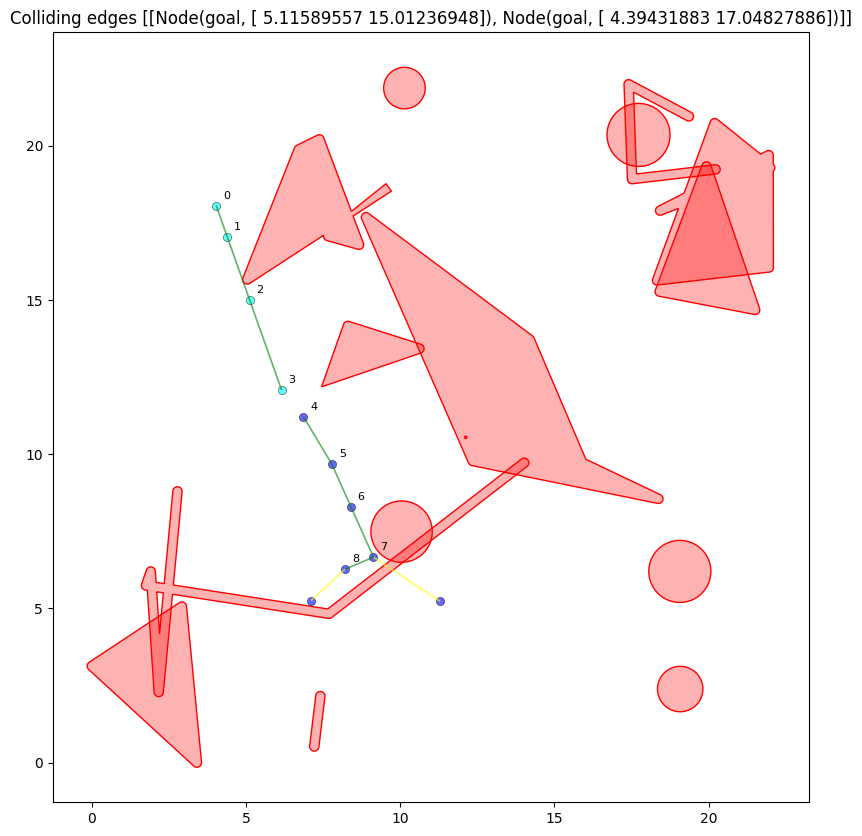

 30%|███       | 3/10 [00:00<00:00, 315.35it/s]


In [ ]:
for i in range(1000):
    benchmark = randomScene.create_random_benchmark(SCENE_LIMITS)
    planner = BidirectionalSBL(benchmark.collisionChecker,{"count_edge_checks":True})
    path = planner.planPath(list(benchmark.startList[0]), list(benchmark.goalList[0]))
    edge_check_counts = planner.collision_check_counter

    # 14.2 Check that no edge is checked for collisions twice
    assert np.any(np.array(list(edge_check_counts.values()))<2), f"Edge doublechecked for collision {edge_check_counts.values()}"

    if path:
        # 14.4 Check that path goes from start to goal point
        assert np.all(path[0].coordinates == benchmark.startList[0]), "Start points not matching"
        assert np.all(path[-1].coordinates == benchmark.goalList[0]), "Goal points not matching"


        # 14.5 Check that all edges on path are collision free (complete line test as reference)
        colliding_edges = []
        for i_node in range(len(path)-2):
            assert not benchmark.collisionChecker.pointInCollision(path[i_node].coordinates), f"Colliding node {path[i_node]}"
            if benchmark.collisionChecker.lineInCollisionExact(path[i_node].coordinates,path[i_node+1].coordinates):
                colliding_edges.append(path[i_node:i_node+2])
        if colliding_edges:
            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(1, 1, 1)
            IPVISsbl.sblVisualize(planner,path,ax)
            ax.set_title(f"Colliding edges {colliding_edges}")
            plt.show()



Most paths do not have any collisions. Sometimes, an edge runs through a tiny section of an obstacle such as a corner or the edge slightly touches the surface. This means that there are only collisions at a very short section of the edge. This is hard to find with an adaptive line test with limited points.